In [78]:
import sys
sys.path.append("../src")
from connect_db import get_engine

In [79]:
engine = get_engine()

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Orders

In [81]:
orders = pd.read_sql(" Select * from orders ", engine)
orders_ml = orders.copy()

In [82]:
orders_ml.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
37164,45dcb58c5c287e7fdf32ba72e75bc177,896dadd858fde9124a92d3a71f046d07,delivered,2017-11-23 17:06:28,2017-11-25 06:16:20,2017-11-28 21:36:03,2017-12-14 15:52:50,2017-12-19
32784,5a87e8c67abd6328a86c6165a91a547d,c01b8d38e70bb40c4a1703933a095d15,delivered,2018-05-03 16:43:36,2018-05-03 17:31:29,2018-05-04 14:46:00,2018-05-16 14:38:21,2018-05-21
82018,730308f506bdb6d00878bc7cce6109f9,1ba85623b286d71c8101ddb6849a15e5,delivered,2017-05-13 17:13:16,2017-05-13 17:25:11,2017-05-15 11:36:12,2017-05-18 09:16:40,2017-05-24
43120,858dc2838532d6ec487b622925f25c56,8a70aa71714e9dacc4dac1a4c4b336b9,delivered,2017-05-15 09:49:01,2017-05-16 03:42:32,2017-05-16 16:40:17,2017-05-22 16:53:06,2017-06-02
71383,69f438e4cdb96fa1ed6bb2dcf499281b,8702a62684cd9a0ad5a391017c6939d6,delivered,2018-06-14 10:44:24,2018-06-14 11:01:29,2018-06-19 17:20:00,2018-06-25 21:36:51,2018-07-12
21751,726dc9c6c71556f7c7ff01eb24278bd9,a3552008b1cf707a84d3c8124acdb7ca,delivered,2017-12-02 18:45:26,2017-12-02 18:57:21,2017-12-05 02:34:26,2017-12-10 15:59:16,2017-12-28
30616,8fee0f490cce11cc2dc792974e21b3d6,6638fe29a1ceb0cad30aa332ee0d59a0,delivered,2018-04-17 13:31:43,2018-04-17 13:51:29,2018-04-18 21:38:38,2018-04-20 14:58:45,2018-05-04
25893,2cc606fca85523eee5d51c8d9defe0a5,09e3aaa17d44116c17b6627e5e9630d7,delivered,2018-07-15 07:08:12,2018-07-17 04:31:35,2018-07-23 11:31:00,2018-07-30 14:57:55,2018-08-13
95386,9f76d1a5ba48abf682161efaadca30a4,9bb8aef52763d98ec854841ba8d8b0d9,delivered,2017-06-19 21:54:46,2017-06-19 22:05:17,2017-06-20 16:12:53,2017-06-29 13:32:03,2017-07-11
58128,74b4e28e0e0a0715ca63940014536bb7,9733e9fce3789a3aa04dc63e1153f8b6,delivered,2018-01-26 01:01:58,2018-01-26 01:13:41,2018-01-26 18:29:18,2018-02-06 22:22:02,2018-02-26


In [83]:
orders_ml["delivery_days"] = (
    pd.to_datetime(orders_ml["order_delivered_customer_date"])
    -
    pd.to_datetime(orders_ml["order_purchase_timestamp"])
).dt.days

In [84]:
orders_ml["is_late"] = (
    pd.to_datetime(orders_ml["order_delivered_customer_date"]).dt.date
    >
    pd.to_datetime(orders_ml["order_estimated_delivery_date"]).dt.date
).astype(int)

In [85]:
orders_ml["purchase_month"] = (pd.to_datetime(orders_ml["order_purchase_timestamp"]).dt.month)

In [86]:
orders_ml["purchase_weekday"] = (pd.to_datetime(orders_ml["order_purchase_timestamp"]).dt.dayofweek)

# Order_Items

In [87]:
order_items = pd.read_sql("Select * from order_items ", engine)

In [88]:
order_items_features = (order_items.groupby("order_id")
                                  .agg(
                                      total_price = ("price","sum"),
                                      total_freight = ("freight_value","sum"),
                                      total_items = ("product_id","count")
                                  )
                                  .reset_index()
    
)
order_items_features

,order_id,total_price,total_freight,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1
...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,1
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,1
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,1
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72,1


# Payments

In [89]:
payments = pd.read_sql(" Select * from payments", engine)

In [90]:
payments_features = (payments.groupby("order_id")
                             .agg(
                                    payment_value=("payment_value","sum"),
                                    payment_installments=( "payment_installments","max"),
                                    payment_type=("payment_type","first")
                                )
                                .reset_index()
)
payments_features

,order_id,payment_value,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card
...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40,1,boleto
99436,fffcd46ef2263f404302a634eb57f7eb,386.53,1,boleto
99437,fffce4705a9662cd70adb13d4a31832d,116.85,3,credit_card
99438,fffe18544ffabc95dfada21779c9644f,64.71,3,credit_card


# Product Feature

In [91]:
products = pd.read_sql(" Select * from products", engine)
category_translation = pd.read_sql(" Select * from category_translation", engine)

In [92]:
products_ml = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [93]:
products_ml

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45,67,2,12300.0,40.0,40.0,40.0,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41,971,1,1700.0,16.0,19.0,16.0,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50,799,1,1400.0,27.0,7.0,27.0,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60,156,2,700.0,31.0,13.0,20.0,computers_accessories


In [94]:
products_ml["product_volume"] = (
    products_ml["product_length_cm"]
    *
    products_ml["product_height_cm"]
    *
    products_ml["product_width_cm"]
)

In [95]:
product_features = (order_items.merge( products_ml, on="product_id")
    .groupby("order_id")
    .agg(
        category_name=("product_category_name_english", "first" ),
        product_weight_g=("product_weight_g","mean"),
        product_volume=("product_volume","mean")
    )
    .reset_index()
)

In [96]:
product_features

,order_id,category_name,product_weight_g,product_volume
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,650.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,30000.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,3050.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,perfumery,200.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,3750.0,42000.0
...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,housewares,10150.0,53400.0
98662,fffcd46ef2263f404302a634eb57f7eb,computers_accessories,8950.0,44460.0
98663,fffce4705a9662cd70adb13d4a31832d,sports_leisure,967.0,9576.0
98664,fffe18544ffabc95dfada21779c9644f,computers_accessories,100.0,8000.0


# Customer Feature

In [97]:
customers = pd.read_sql(" Select * from customers", engine)

In [98]:
customer_features = (
     orders[["order_id","customer_id"]]
    .merge(customers[["customer_id","customer_state"]],
        on="customer_id"
    )
)

# Target

In [99]:
reviews = pd.read_sql("Select * from reviews", engine)

In [100]:
target = reviews[["order_id", "review_score"]]

In [101]:
target

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5
...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,5
99220,22ec9f0669f784db00fa86d035cf8602,5
99221,55d4004744368f5571d1f590031933e4,5
99222,7725825d039fc1f0ceb7635e3f7d9206,4


In [102]:
df_ml = target

In [103]:
df_ml = df_ml.merge( orders_ml[
        ["order_id","delivery_days","is_late","purchase_month","purchase_weekday"]
    ],
    on="order_id"
)

In [104]:
df_ml = df_ml.merge(order_items_features,on="order_id")
df_ml = df_ml.merge(payments_features,on="order_id")
df_ml = df_ml.merge(customer_features[[ "order_id", "customer_state"]],on="order_id")
df_ml = df_ml.merge(product_features,on="order_id")


In [105]:
df_ml.shape

(98464, 16)

In [106]:
df_ml.columns

Index(['order_id', 'review_score', 'delivery_days', 'is_late',
       'purchase_month', 'purchase_weekday', 'total_price', 'total_freight',
       'total_items', 'payment_value', 'payment_installments', 'payment_type',
       'customer_state', 'category_name', 'product_weight_g',
       'product_volume'],
      dtype='object')

In [107]:
df_ml

,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume
0,73fc7af87114b39712e6da79b0a377eb,4,6.0,0,1,3,370.00,27.26,2,397.26,8,credit_card,SP,sports_leisure,1300.0,31500.0
1,a548910a1c6147796b98fdf73dbeba33,5,9.0,0,2,2,79.79,8.30,1,88.09,1,credit_card,SP,computers_accessories,245.0,3724.0
2,f9e4b658b201a9f2ecdecbb34bed034b,5,13.0,0,2,5,149.00,45.12,1,194.12,1,credit_card,BA,computers_accessories,6550.0,8000.0
3,658677c97b385a9be170737859d3511b,5,10.0,0,4,6,179.99,42.85,1,222.84,1,credit_card,SC,garden_tools,7650.0,8000.0
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,18.0,0,2,5,1199.00,134.25,1,1333.25,10,credit_card,SC,sports_leisure,9850.0,183750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98459,2a8c23fee101d4d5662fa670396eb8da,5,8.0,0,6,2,226.77,61.20,1,287.97,8,credit_card,GO,furniture_decor,7250.0,62500.0
98460,22ec9f0669f784db00fa86d035cf8602,5,4.0,0,12,6,199.99,9.77,1,209.76,1,credit_card,RJ,toys,2363.0,11799.0
98461,55d4004744368f5571d1f590031933e4,5,3.0,0,3,6,215.97,15.59,1,231.56,6,credit_card,MG,stationery,4100.0,42920.0
98462,7725825d039fc1f0ceb7635e3f7d9206,4,7.0,0,6,4,50.95,15.46,1,66.41,1,credit_card,MG,sports_leisure,600.0,1760.0


In [108]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98464 entries, 0 to 98463
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              98464 non-null  object 
 1   review_score          98464 non-null  int64  
 2   delivery_days         96358 non-null  float64
 3   is_late               98464 non-null  int64  
 4   purchase_month        98464 non-null  int32  
 5   purchase_weekday      98464 non-null  int32  
 6   total_price           98464 non-null  float64
 7   total_freight         98464 non-null  float64
 8   total_items           98464 non-null  int64  
 9   payment_value         98464 non-null  float64
 10  payment_installments  98464 non-null  int64  
 11  payment_type          98464 non-null  object 
 12  customer_state        98464 non-null  object 
 13  category_name         97055 non-null  object 
 14  product_weight_g      98464 non-null  float64
 15  product_volume     

In [109]:
df_ml.isnull().sum()

order_id                   0
review_score               0
delivery_days           2106
is_late                    0
purchase_month             0
purchase_weekday           0
total_price                0
total_freight              0
total_items                0
payment_value              0
payment_installments       0
payment_type               0
customer_state             0
category_name           1409
product_weight_g           0
product_volume             0
dtype: int64

In [110]:
df_ml[df_ml["delivery_days"].isna()].head()

,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume
19,583174fbe37d3d5f0d6661be3aad1786,1,NaN,0,8,5,89.90,9.38,1,99.28,2,credit_card,SP,luggage_accessories,550.0,23625.0
68,97d2f8fe76f2f253b8291e17b5383884,1,NaN,0,10,2,279.99,121.20,1,401.19,10,credit_card,MT,auto,24000.0,134871.0
89,a2714ecbf6eeb3bb9cd7dba6dc1c5e82,1,NaN,0,2,2,99.80,33.97,1,133.77,1,credit_card,SP,housewares,11250.0,48000.0
104,96b947c986b42f213c9e6b8ccccedb89,3,NaN,0,7,0,380.00,79.63,1,459.63,1,boleto,RJ,office_furniture,20850.0,55000.0
150,7e63ea5a0a34684140ae0e51ebe53035,5,NaN,0,4,2,29.99,50.85,1,80.84,8,credit_card,PI,telephony,300.0,816.0


In [111]:
df_ml = df_ml.dropna(subset=["delivery_days"])

In [112]:
df_ml[ df_ml["category_name"].isna()].head()

,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume
176,4edd97a383a190e45e83c16cd6460d63,5,18.0,0,2,0,13.30,15.10,1,28.40,1,boleto,RJ,None,350.0,640.0
354,9d7f2c9f33008498700ffdc3162878fb,5,4.0,0,8,6,99.77,14.45,1,114.22,2,credit_card,PR,None,300.0,2240.0
440,7dd12269fb63d70af90a488dc5e90876,5,9.0,0,4,5,34.90,18.23,1,53.13,1,credit_card,RJ,None,100.0,1452.0
480,049ede3fc839758e81752a9dacd1f911,5,7.0,0,8,3,12.99,12.79,1,25.78,1,boleto,SP,None,250.0,1408.0
621,8d48068c3ecbc21886a881562c96d7fa,2,10.0,0,9,5,23.00,17.92,1,40.92,4,credit_card,MG,None,800.0,3344.0


In [113]:
df_ml["category_name"] = (df_ml["category_name"].fillna("Unknown"))

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20484\2786699757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["category_name"] = (df_ml["category_name"].fillna("Unknown"))


In [114]:
df_ml.isnull().sum()

order_id                0
review_score            0
delivery_days           0
is_late                 0
purchase_month          0
purchase_weekday        0
total_price             0
total_freight           0
total_items             0
payment_value           0
payment_installments    0
payment_type            0
customer_state          0
category_name           0
product_weight_g        0
product_volume          0
dtype: int64

In [115]:
df_ml.shape

(96358, 16)

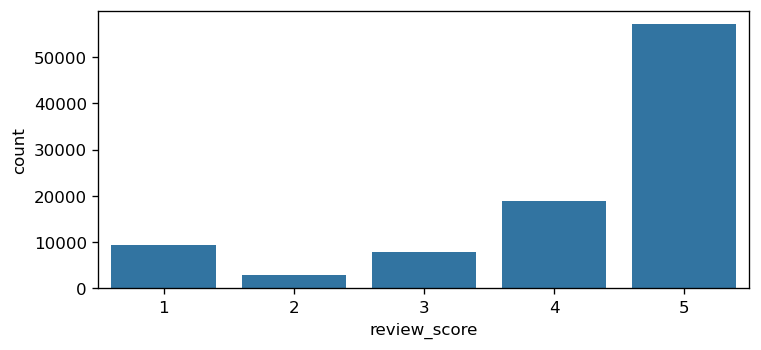

In [116]:
sns.countplot(data=df_ml,x="review_score")
plt.show()

In [117]:
df_ml["review_target"] = ( df_ml["review_score"] >= 4).astype(int)

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_20484\3366392228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["review_target"] = ( df_ml["review_score"] >= 4).astype(int)


In [118]:
df_ml.sample()

,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume,review_target
50619,edd63d440fff63cfb4a5d662945a6a28,5,4.0,0,8,1,119.9,23.99,1,143.89,2,credit_card,RJ,toys,1050.0,14820.0,1


In [119]:
df_ml["review_target"].value_counts()

review_target
1    76047
0    20311
Name: count, dtype: int64

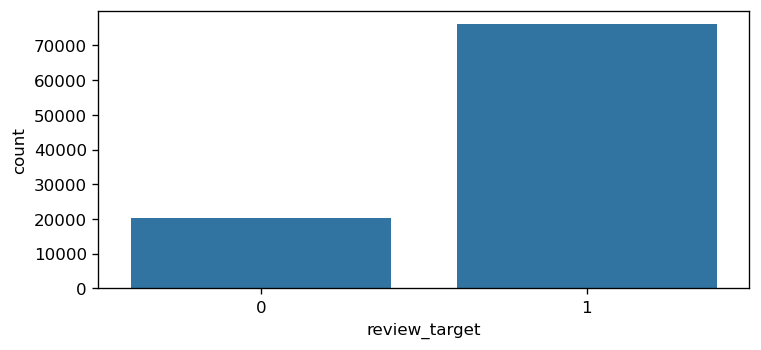

In [120]:
sns.countplot(data=df_ml,x="review_target")
plt.show()

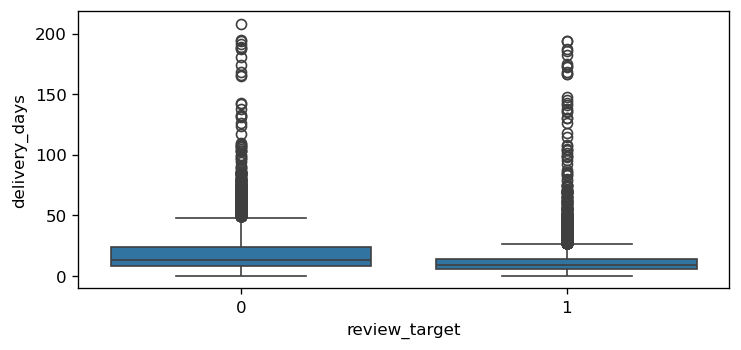

In [121]:
sns.boxplot(
    data=df_ml,
    x="review_target",
    y="delivery_days"
)
plt.show()

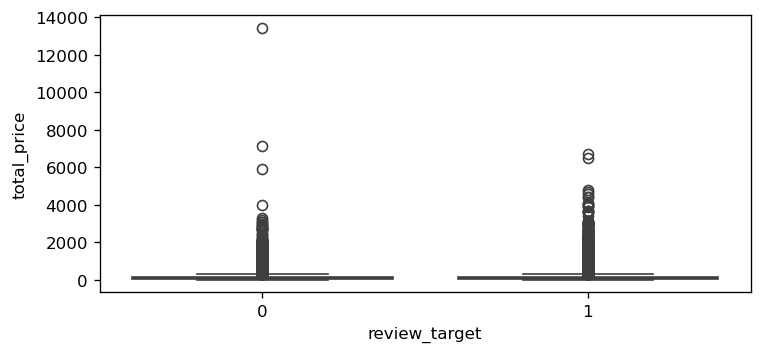

In [122]:
sns.boxplot(data=df_ml,x="review_target",y="total_price")
plt.show()

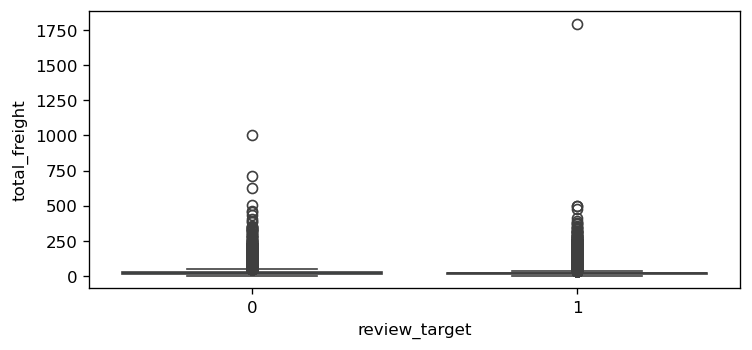

In [123]:
sns.boxplot(data=df_ml,x="review_target",y="total_freight")
plt.show()

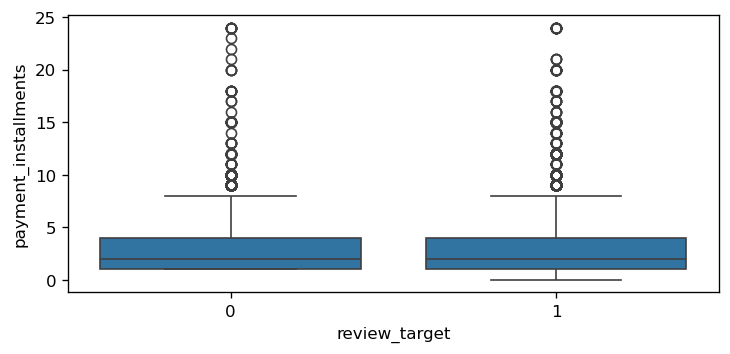

In [124]:
sns.boxplot(data=df_ml, x="review_target",y="payment_installments")
plt.show()

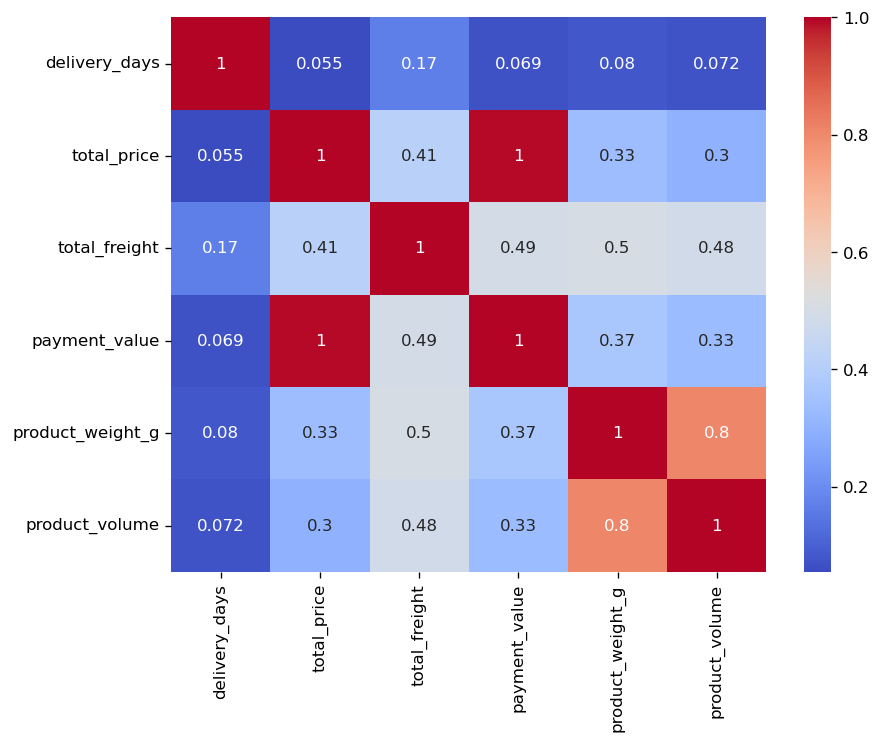

In [125]:
num_cols = [
    "delivery_days",
    "total_price",
    "total_freight",
    "payment_value",
    "product_weight_g",
    "product_volume"
]
plt.figure(figsize=(8,6))
sns.heatmap(df_ml[num_cols].corr(),annot=True,cmap="coolwarm")
plt.show()

In [126]:
df_ml.sample(10)

,order_id,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume,review_target
8979,06a10466a6e3befcdcb37637948fea4a,5,4.0,0,12,3,68.00,16.54,2,84.54,1,credit_card,RN,books_general_interest,300.0,1012.0,1
12583,34f44d3f393579e65a58c014b825cf81,3,14.0,0,3,1,99.99,23.28,1,123.27,10,credit_card,RS,cool_stuff,1200.0,15750.0,0
30729,979413f37ff3d29ddcd3bdb3ec55df41,5,4.0,0,8,3,59.00,7.78,1,66.78,5,credit_card,SP,stationery,500.0,2688.0,1
77439,1103c4be46dcfaefc2a3b79d3ef6c866,4,9.0,0,8,0,139.90,19.08,1,158.98,1,boleto,RS,cool_stuff,500.0,4224.0,1
26820,063929a628206b3f69eaaa2e003ca695,5,9.0,0,12,5,120.00,20.33,1,140.33,2,credit_card,DF,pet_shop,1150.0,24000.0,1
98306,f7f84dc96924f895eeee8f89515012c3,5,20.0,0,9,1,9.90,15.10,1,25.00,1,boleto,SC,housewares,100.0,2457.0,1
95698,05906ff9618d78153208c80165d91b2c,4,9.0,0,4,6,109.90,23.31,1,133.21,1,credit_card,DF,auto,1750.0,27000.0,1
74468,a9ddf1f40e51ec5d1c828564cef4d92e,5,9.0,0,6,2,18.80,15.10,1,33.90,3,credit_card,SP,toys,175.0,3840.0,1
34018,47eb16c7c5c5142c9c161ba03eb77d91,4,20.0,0,4,4,149.94,40.12,1,190.06,1,credit_card,RJ,office_furniture,12650.0,52488.0,1
47941,51d967125c0a12392dfdd135be86ab3a,5,12.0,0,9,4,181.00,21.76,1,202.76,1,credit_card,RS,sports_leisure,2000.0,6624.0,1


In [127]:
df_ml = df_ml.drop(columns=["order_id"])


In [128]:
df_ml.isnull().sum()

review_score            0
delivery_days           0
is_late                 0
purchase_month          0
purchase_weekday        0
total_price             0
total_freight           0
total_items             0
payment_value           0
payment_installments    0
payment_type            0
customer_state          0
category_name           0
product_weight_g        0
product_volume          0
review_target           0
dtype: int64

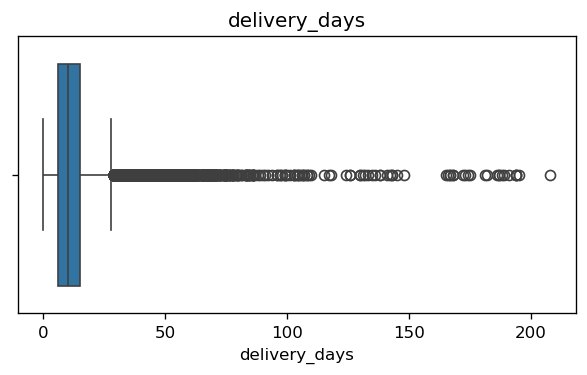

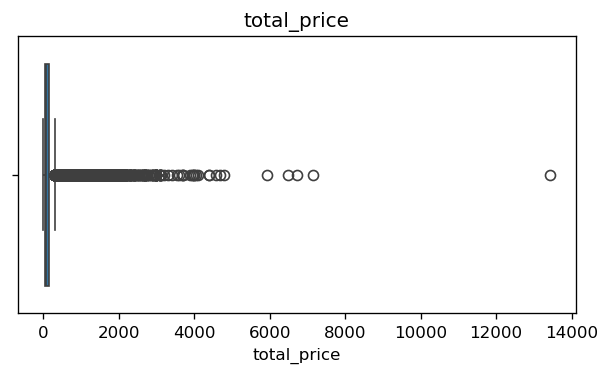

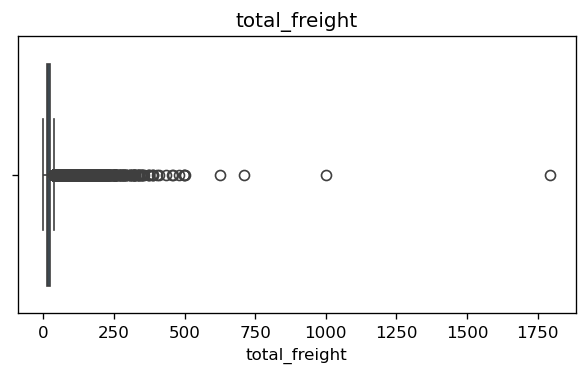

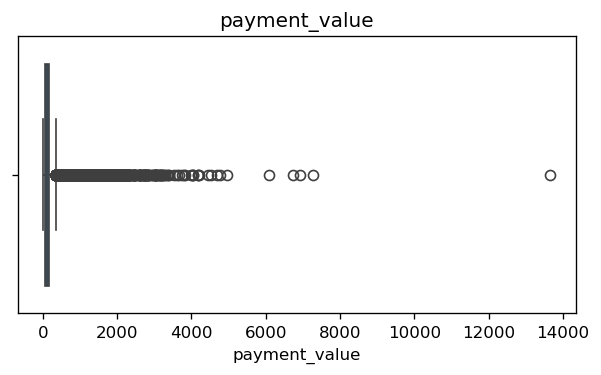

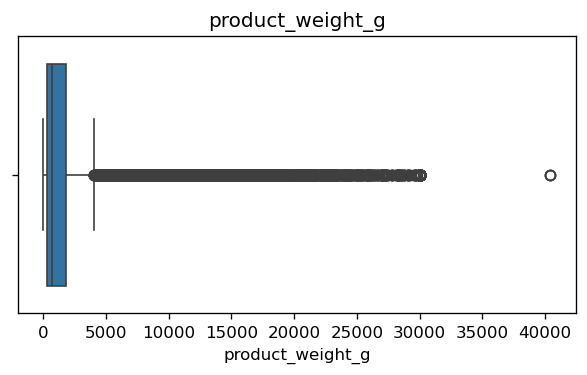

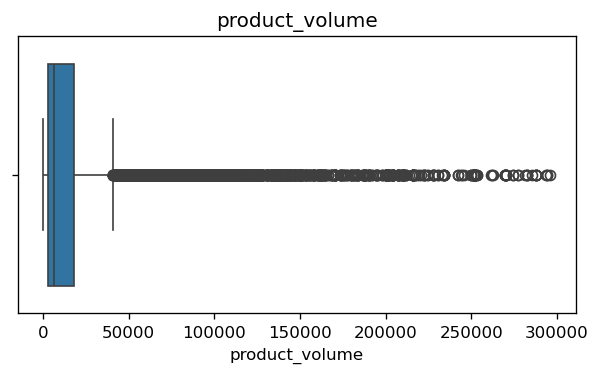

In [129]:
num_cols = [
    "delivery_days",
    "total_price",
    "total_freight",
    "payment_value",
    "product_weight_g",
    "product_volume"
]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_ml[col])
    plt.title(col)
    plt.show()

In [130]:
df_ml

,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,payment_type,customer_state,category_name,product_weight_g,product_volume,review_target
0,4,6.0,0,1,3,370.00,27.26,2,397.26,8,credit_card,SP,sports_leisure,1300.0,31500.0,1
1,5,9.0,0,2,2,79.79,8.30,1,88.09,1,credit_card,SP,computers_accessories,245.0,3724.0,1
2,5,13.0,0,2,5,149.00,45.12,1,194.12,1,credit_card,BA,computers_accessories,6550.0,8000.0,1
3,5,10.0,0,4,6,179.99,42.85,1,222.84,1,credit_card,SC,garden_tools,7650.0,8000.0,1
4,5,18.0,0,2,5,1199.00,134.25,1,1333.25,10,credit_card,SC,sports_leisure,9850.0,183750.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98459,5,8.0,0,6,2,226.77,61.20,1,287.97,8,credit_card,GO,furniture_decor,7250.0,62500.0,1
98460,5,4.0,0,12,6,199.99,9.77,1,209.76,1,credit_card,RJ,toys,2363.0,11799.0,1
98461,5,3.0,0,3,6,215.97,15.59,1,231.56,6,credit_card,MG,stationery,4100.0,42920.0,1
98462,4,7.0,0,6,4,50.95,15.46,1,66.41,1,credit_card,MG,sports_leisure,600.0,1760.0,1


In [131]:
from sklearn.preprocessing import OneHotEncoder

In [132]:
cat_cols = ["payment_type","customer_state","category_name"]

In [133]:
df_ml = pd.get_dummies(df_ml,columns=cat_cols,drop_first=True)

In [134]:
df_ml.head()

,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,...,category_name_security_and_services,category_name_signaling_and_security,category_name_small_appliances,category_name_small_appliances_home_oven_and_coffee,category_name_sports_leisure,category_name_stationery,category_name_tablets_printing_image,category_name_telephony,category_name_toys,category_name_watches_gifts
0,4,6.0,0,1,3,370.00,27.26,2,397.26,8,...,False,False,False,False,True,False,False,False,False,False
1,5,9.0,0,2,2,79.79,8.30,1,88.09,1,...,False,False,False,False,False,False,False,False,False,False
2,5,13.0,0,2,5,149.00,45.12,1,194.12,1,...,False,False,False,False,False,False,False,False,False,False
3,5,10.0,0,4,6,179.99,42.85,1,222.84,1,...,False,False,False,False,False,False,False,False,False,False
4,5,18.0,0,2,5,1199.00,134.25,1,1333.25,10,...,False,False,False,False,True,False,False,False,False,False


In [135]:
df_ml.dtypes

review_score                              int64
delivery_days                           float64
is_late                                   int64
purchase_month                            int32
purchase_weekday                          int32
                                         ...   
category_name_stationery                   bool
category_name_tablets_printing_image       bool
category_name_telephony                    bool
category_name_toys                         bool
category_name_watches_gifts                bool
Length: 113, dtype: object

In [136]:
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = (df_ml[bool_cols].astype(int))

In [137]:
df_ml

,review_score,delivery_days,is_late,purchase_month,purchase_weekday,total_price,total_freight,total_items,payment_value,payment_installments,...,category_name_security_and_services,category_name_signaling_and_security,category_name_small_appliances,category_name_small_appliances_home_oven_and_coffee,category_name_sports_leisure,category_name_stationery,category_name_tablets_printing_image,category_name_telephony,category_name_toys,category_name_watches_gifts
0,4,6.0,0,1,3,370.00,27.26,2,397.26,8,...,0,0,0,0,1,0,0,0,0,0
1,5,9.0,0,2,2,79.79,8.30,1,88.09,1,...,0,0,0,0,0,0,0,0,0,0
2,5,13.0,0,2,5,149.00,45.12,1,194.12,1,...,0,0,0,0,0,0,0,0,0,0
3,5,10.0,0,4,6,179.99,42.85,1,222.84,1,...,0,0,0,0,0,0,0,0,0,0
4,5,18.0,0,2,5,1199.00,134.25,1,1333.25,10,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98459,5,8.0,0,6,2,226.77,61.20,1,287.97,8,...,0,0,0,0,0,0,0,0,0,0
98460,5,4.0,0,12,6,199.99,9.77,1,209.76,1,...,0,0,0,0,0,0,0,0,1,0
98461,5,3.0,0,3,6,215.97,15.59,1,231.56,6,...,0,0,0,0,0,1,0,0,0,0
98462,4,7.0,0,6,4,50.95,15.46,1,66.41,1,...,0,0,0,0,1,0,0,0,0,0


In [152]:
X = df_ml.drop(columns=["review_score", "review_target"])
y = df_ml["review_target"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size= 0.3, random_state= 1, stratify=y)

In [153]:
from imblearn.over_sampling import SMOTE
Oversample = SMOTE()
X_train, y_train = Oversample.fit_resample(X_train, y_train)

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
acc = []
for i in range(1,51):
    rf = RandomForestClassifier(n_estimators= i)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test,y_pred))
    

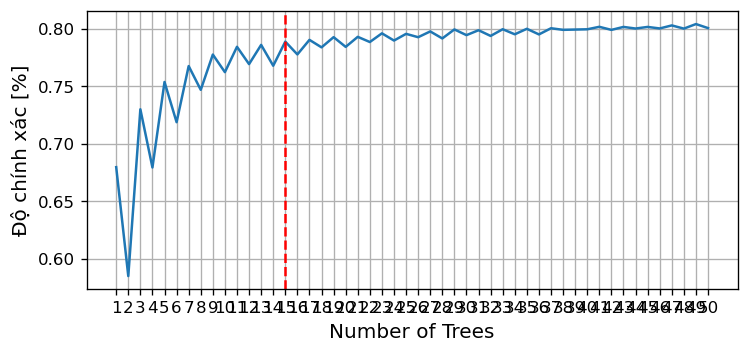

In [156]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]', fontsize = 12)
plt.xlabel('Number of Trees', fontsize = 12)
plt.plot(range(1,51),acc)
plt.xticks(range(1,51))
plt.axvline(x = 15, color = 'r', linestyle = '--')
plt.grid('minor')

In [158]:
rf = RandomForestClassifier(n_estimators=49)
rf.fit(X_train, y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8021654905216549

In [159]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.56      0.29      0.38      6093
           1       0.83      0.94      0.88     22815

    accuracy                           0.80     28908
   macro avg       0.70      0.61      0.63     28908
weighted avg       0.77      0.80      0.78     28908



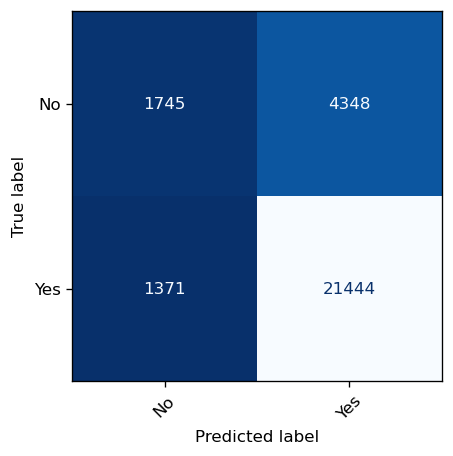

In [160]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['No', 'Yes']
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="Blues_r")

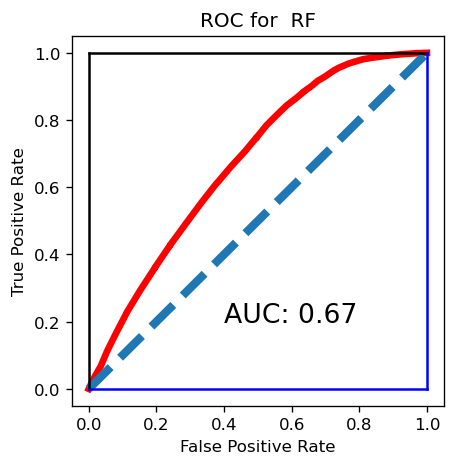

In [161]:
from sklearn.metrics import roc_auc_score,roc_curve
y_probabilities = rf.predict_proba(X_test)[:,1]
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test,y_probabilities)
plt.figure(figsize=(4,4))
plt.title('ROC for  RF')
plt.plot(false_positive_rate, true_positive_rate, linewidth=4, color='red')
plt.plot([0,1],ls='--',linewidth=5)
plt.plot([0,0],[1,0],c='0')
plt.plot([1,1],c='0')
plt.plot([0,0],c='b')
plt.plot([1,1],[1,0],c='b')
plt.text(0.4,0.2,'AUC: {:.2f}'.format(roc_auc_score(y_test,y_probabilities)),size= 16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [162]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
0,delivery_days,0.121418
5,total_freight,0.071299
7,payment_value,0.062083
10,product_volume,0.059943
4,total_price,0.059382
9,product_weight_g,0.057301
38,customer_state_SP,0.055084
3,purchase_weekday,0.047362
2,purchase_month,0.046024
8,payment_installments,0.037959


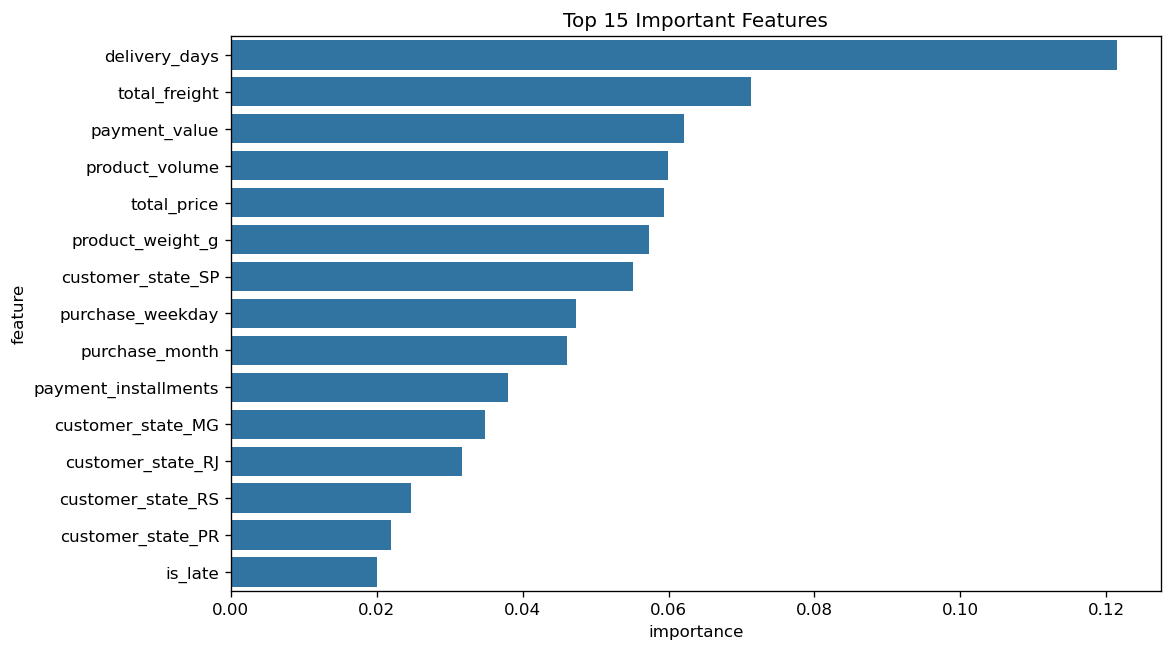

In [ ]:
top15 = importance.head(15)
plt.figure(figsize=(10,6))
sns.barplot( data=top15,x="importance",y="feature")
plt.title("Top 15 Important Features")
plt.show()